# From Transformer to Volatility-Aware Attention (VAA)

**A complete walkthrough: attention mechanics → financial time series → GARCH → our innovation**

This notebook builds understanding layer by layer. Every concept is visualized.

---

## Table of Contents

| Part | Topic | Key Question |
|------|-------|--------------|
| 1 | Dot-Product Attention | How does a model decide "what to look at"? |
| 2 | **Temperature & Softmax** | How does sharpness of attention change with temperature? |
| 3 | Multi-Head Attention | Why use multiple attention heads? |
| 4 | Full Transformer Encoder | How do all pieces fit together? |
| 5 | Transformers for Financial Time Series | How does stock data flow through a Transformer? |
| 6 | Volatility & GARCH | What is volatility and how does GARCH model it? |
| 7 | Existing Approaches (GARCH+NN) | What has already been done? |
| 8 | **Our Innovation: VAA** | How does volatility-aware temperature work? |
| 9 | The Three Proposals Compared | Which direction to take? |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Color scheme
C_BLUE = '#2196F3'
C_RED = '#F44336'
C_GREEN = '#4CAF50'
C_ORANGE = '#FF9800'
C_PURPLE = '#9C27B0'

print('Setup complete.')

Setup complete.


---
# Part 1: Dot-Product Attention

## The Core Idea

Attention answers one question: **"Given where I am now, which parts of the input should I focus on?"**

### Analogy
Imagine you're reading today's stock price and want to understand it by looking at the past 10 days. Not all 10 days are equally relevant — maybe day 3 and day 7 had similar patterns. Attention lets the model **automatically learn** which past days to weight heavily.

### The Math (3 steps)

Given an input sequence of length $L$ with dimension $d$:

**Step 1: Create Q, K, V** (three different "views" of the same data)
$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V$$

- $Q$ (Query): "What am I looking for?"
- $K$ (Key): "What do I contain?"
- $V$ (Value): "What information do I carry?"

**Step 2: Compute similarity** (which keys match my query?)
$$\text{scores} = QK^T$$

**Step 3: Normalize & aggregate**
$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

The $\sqrt{d_k}$ is **scaling** — we'll see why this matters enormously in Part 2.

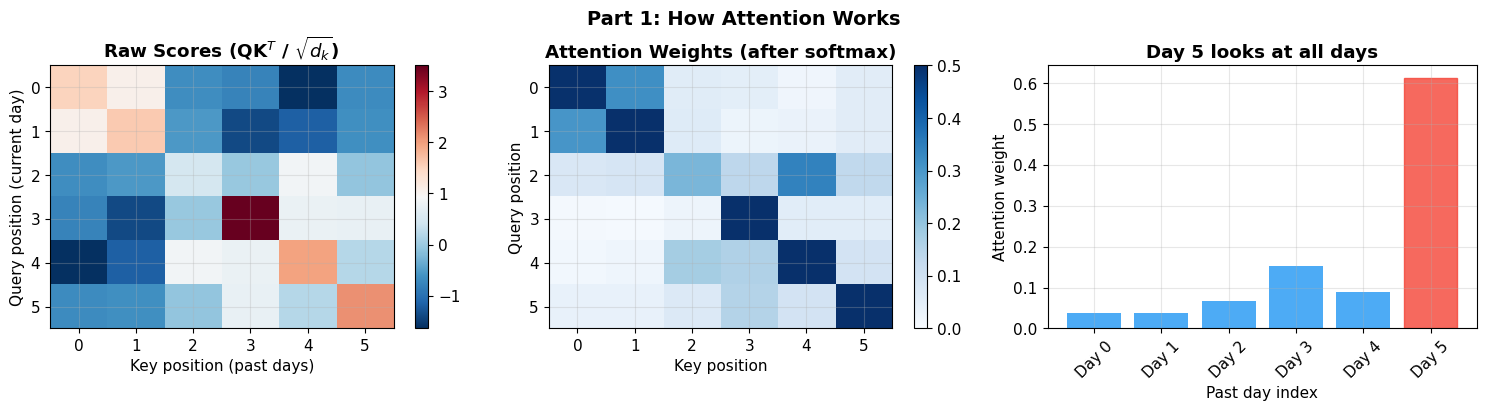

Each row of the attention matrix sums to 1: [1. 1. 1. 1. 1. 1.]

Day 5 pays most attention to Day 5
Attention distribution for Day 5: [0.037 0.039 0.067 0.154 0.09  0.613]


In [2]:
def softmax(x, axis=-1):
    """Numerically stable softmax."""
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V, temperature=None):
    """
    Q, K, V: [seq_len, d_k]
    temperature: scalar divisor (default: sqrt(d_k))
    """
    d_k = Q.shape[-1]
    if temperature is None:
        temperature = np.sqrt(d_k)
    
    scores = Q @ K.T / temperature  # [seq_len, seq_len]
    weights = softmax(scores)        # [seq_len, seq_len]
    output = weights @ V             # [seq_len, d_k]
    return output, weights, scores

# Demo: 6 time steps, 4-dimensional features
np.random.seed(42)
seq_len, d_k = 6, 4
X = np.random.randn(seq_len, d_k)

# Simple identity projections for clarity
Q, K, V = X.copy(), X.copy(), X.copy()

output, weights, scores = scaled_dot_product_attention(Q, K, V)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw scores
im0 = axes[0].imshow(scores, cmap='RdBu_r', aspect='auto')
axes[0].set_title('Raw Scores (QK$^T$ / $\sqrt{d_k}$)', fontweight='bold')
axes[0].set_xlabel('Key position (past days)')
axes[0].set_ylabel('Query position (current day)')
plt.colorbar(im0, ax=axes[0])

# Attention weights
im1 = axes[1].imshow(weights, cmap='Blues', aspect='auto', vmin=0, vmax=0.5)
axes[1].set_title('Attention Weights (after softmax)', fontweight='bold')
axes[1].set_xlabel('Key position')
axes[1].set_ylabel('Query position')
plt.colorbar(im1, ax=axes[1])

# Bar chart for one query
query_idx = 5  # last time step
bars = axes[2].bar(range(seq_len), weights[query_idx], color=C_BLUE, alpha=0.8)
bars[query_idx].set_color(C_RED)
axes[2].set_title(f'Day {query_idx} looks at all days', fontweight='bold')
axes[2].set_xlabel('Past day index')
axes[2].set_ylabel('Attention weight')
axes[2].set_xticks(range(seq_len))
axes[2].set_xticklabels([f'Day {i}' for i in range(seq_len)], rotation=45)

plt.tight_layout()
plt.suptitle('Part 1: How Attention Works', fontweight='bold', y=1.02, fontsize=14)
plt.show()

print(f'Each row of the attention matrix sums to 1: {weights.sum(axis=1).round(3)}')
print(f'\nDay 5 pays most attention to Day {np.argmax(weights[5])}')
print(f'Attention distribution for Day 5: {weights[5].round(3)}')

### Key Takeaway
- Each position (day) computes how much to attend to every other position
- The attention weights are a **probability distribution** (sums to 1)
- The diagonal is often strong (each day attends to itself), but not always

**Question to keep in mind**: What if we could control HOW spread out vs. focused these weights are?

---
# Part 2: Temperature & Softmax — THE Critical Concept

This is **the single most important concept** for understanding our VAA innovation.

## What is softmax temperature?

Standard attention divides by $\sqrt{d_k}$:
$$\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)$$

But what if we replace $\sqrt{d_k}$ with a variable $\tau$ (temperature)?
$$\text{softmax}\left(\frac{QK^T}{\tau}\right)$$

The temperature $\tau$ controls the **sharpness** of the attention distribution:

| $\tau$ value | Effect | Attention looks like | Analogy |
|:---:|:---:|:---:|:---:|
| Very small (→0) | Scores amplified | One-hot (winner-take-all) | Looking through a sniper scope |
| $\sqrt{d_k}$ (default) | Normal scaling | Balanced distribution | Normal vision |
| Very large | Scores compressed | Uniform (equal weights) | Panoramic wide-angle lens |

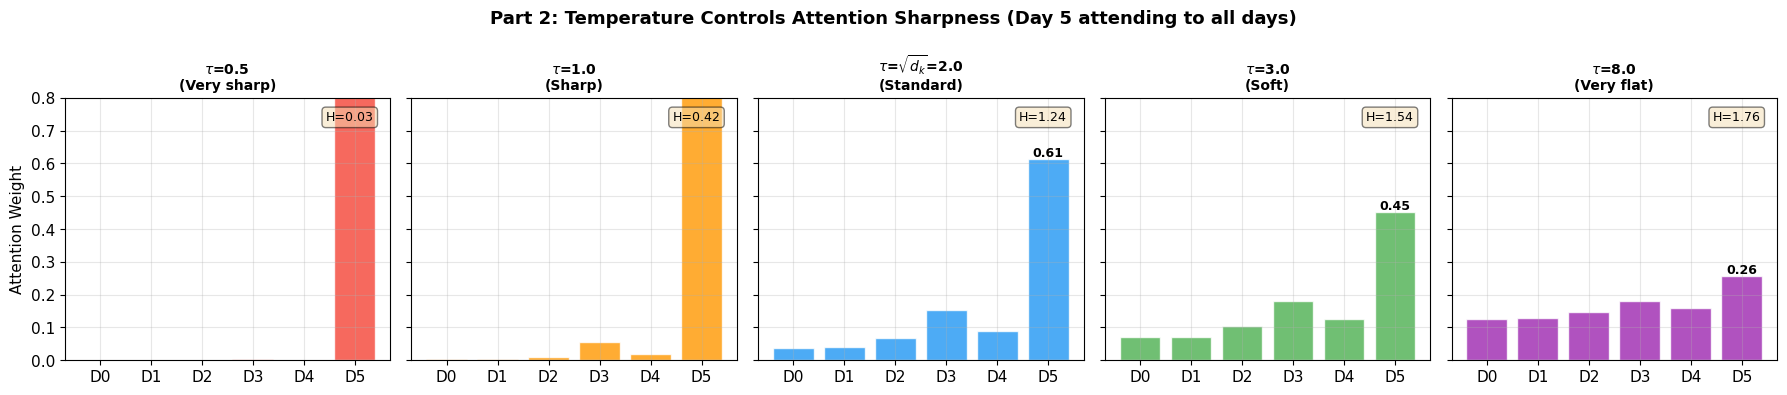

H = Shannon entropy. Higher H = more spread out attention.

This is the ENTIRE basis of our VAA innovation:
  If we can SET the temperature based on market conditions,
  we control HOW the model distributes its attention.


In [3]:
# THE key visualization: temperature controls attention sharpness

temperatures = [0.5, 1.0, np.sqrt(d_k), 3.0, 8.0]
temp_labels = ['$\\tau$=0.5\n(Very sharp)', '$\\tau$=1.0\n(Sharp)', 
               f'$\\tau$=$\\sqrt{{d_k}}$={np.sqrt(d_k):.1f}\n(Standard)', 
               '$\\tau$=3.0\n(Soft)', '$\\tau$=8.0\n(Very flat)']
temp_colors = [C_RED, C_ORANGE, C_BLUE, C_GREEN, C_PURPLE]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

query_idx = 5
raw_scores = Q[query_idx] @ K.T  # unscaled scores for this query

for i, (tau, label, color) in enumerate(zip(temperatures, temp_labels, temp_colors)):
    scaled = raw_scores / tau
    w = softmax(scaled)
    
    bars = axes[i].bar(range(seq_len), w, color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(label, fontweight='bold', fontsize=10)
    axes[i].set_xticks(range(seq_len))
    axes[i].set_xticklabels([f'D{j}' for j in range(seq_len)])
    axes[i].set_ylim(0, 0.8)
    
    # Annotate max weight
    max_idx = np.argmax(w)
    axes[i].annotate(f'{w[max_idx]:.2f}', (max_idx, w[max_idx]), 
                     ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # Show entropy (measure of spread)
    entropy = -np.sum(w * np.log(w + 1e-10))
    axes[i].text(0.95, 0.95, f'H={entropy:.2f}', transform=axes[i].transAxes,
                ha='right', va='top', fontsize=9, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0].set_ylabel('Attention Weight')
fig.suptitle('Part 2: Temperature Controls Attention Sharpness (Day 5 attending to all days)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('H = Shannon entropy. Higher H = more spread out attention.')
print('\nThis is the ENTIRE basis of our VAA innovation:')
print('  If we can SET the temperature based on market conditions,')
print('  we control HOW the model distributes its attention.')

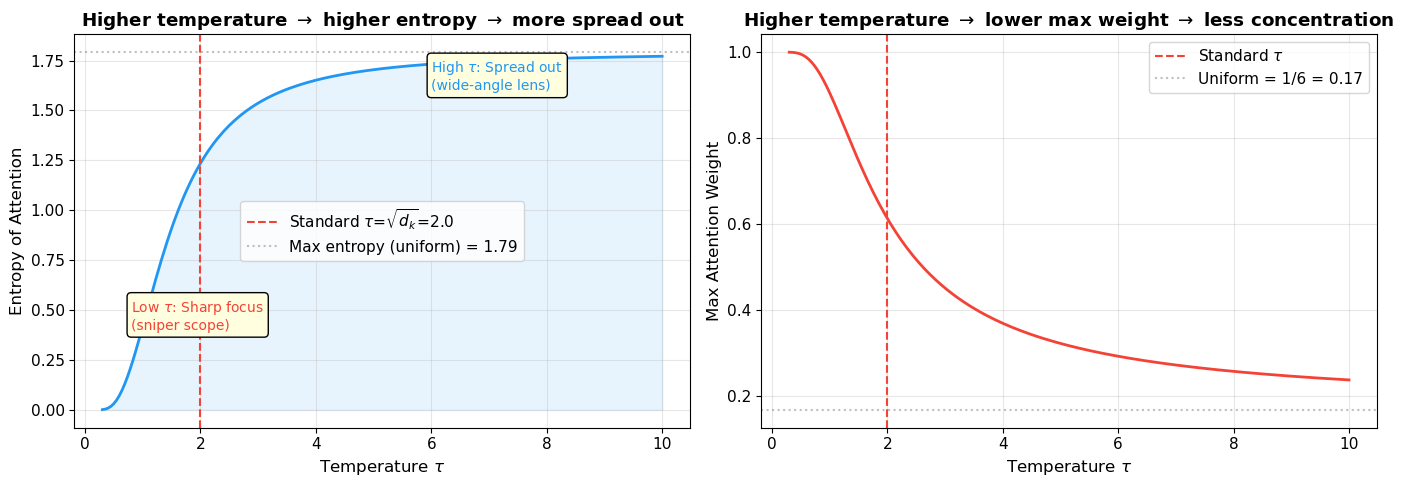

REMEMBER THIS RELATIONSHIP:
  temperature UP   → attention FLAT   → model looks at EVERYTHING equally
  temperature DOWN → attention SHARP  → model focuses on FEW key points


In [4]:
# Continuous view: temperature vs entropy vs max-weight

tau_range = np.linspace(0.3, 10.0, 200)
entropies = []
max_weights = []

for tau in tau_range:
    w = softmax(raw_scores / tau)
    entropies.append(-np.sum(w * np.log(w + 1e-10)))
    max_weights.append(np.max(w))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(tau_range, entropies, color=C_BLUE, linewidth=2)
ax1.axvline(np.sqrt(d_k), color=C_RED, linestyle='--', label=f'Standard $\\tau$=$\\sqrt{{d_k}}$={np.sqrt(d_k):.1f}')
ax1.axhline(np.log(seq_len), color='gray', linestyle=':', alpha=0.5, label=f'Max entropy (uniform) = {np.log(seq_len):.2f}')
ax1.fill_between(tau_range, entropies, alpha=0.1, color=C_BLUE)
ax1.set_xlabel('Temperature $\\tau$', fontsize=12)
ax1.set_ylabel('Entropy of Attention', fontsize=12)
ax1.set_title('Higher temperature $\\rightarrow$ higher entropy $\\rightarrow$ more spread out', fontweight='bold')
ax1.legend()

# Annotate regions
ax1.annotate('Low $\\tau$: Sharp focus\n(sniper scope)', xy=(0.8, 0.4), fontsize=10, color=C_RED,
            bbox=dict(boxstyle='round', facecolor='lightyellow'))
ax1.annotate('High $\\tau$: Spread out\n(wide-angle lens)', xy=(6, 1.6), fontsize=10, color=C_BLUE,
            bbox=dict(boxstyle='round', facecolor='lightyellow'))

ax2.plot(tau_range, max_weights, color=C_RED, linewidth=2)
ax2.axvline(np.sqrt(d_k), color=C_RED, linestyle='--', label=f'Standard $\\tau$')
ax2.axhline(1/seq_len, color='gray', linestyle=':', alpha=0.5, label=f'Uniform = 1/{seq_len} = {1/seq_len:.2f}')
ax2.set_xlabel('Temperature $\\tau$', fontsize=12)
ax2.set_ylabel('Max Attention Weight', fontsize=12)
ax2.set_title('Higher temperature $\\rightarrow$ lower max weight $\\rightarrow$ less concentration', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print('REMEMBER THIS RELATIONSHIP:')
print('  temperature UP   → attention FLAT   → model looks at EVERYTHING equally')
print('  temperature DOWN → attention SHARP  → model focuses on FEW key points')

### Why Does This Matter for Finance?

Think about two market regimes:

1. **Bull market, low volatility**: Price follows a clear trend. The model should **focus sharply** on the dominant trend signal → **low temperature**

2. **Crisis, high volatility**: Everything is chaotic. No single past day is a reliable predictor. The model should **spread attention broadly** to avoid being misled by any single noisy signal → **high temperature**

**This is a design hypothesis, not proven fact.** The opposite could also be true (in a crash, only the last few days matter). We'll need experiments to validate it. But it's a reasonable and testable starting hypothesis.

Standard Transformer uses fixed $\tau = \sqrt{d_k}$ regardless of market conditions. **Our key question: what if $\tau$ adapts to volatility?**

---
# Part 3: Multi-Head Attention

## Why multiple heads?

One attention head can only learn **one** type of relationship. But financial data has multiple simultaneously relevant patterns:
- Short-term momentum (yesterday's trend continues)
- Mean reversion (price returns to average)
- Volatility clustering (volatile days follow volatile days)

**Multi-Head Attention**: run attention $h$ times in parallel, each with different learned projections, then concatenate.

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O$$
$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

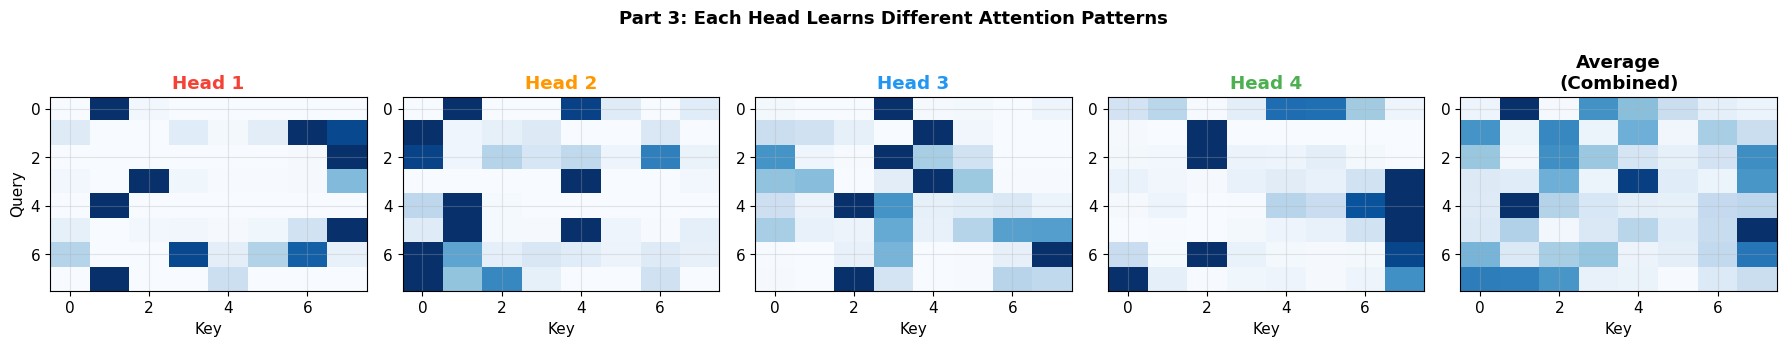

Notice: each head has a DIFFERENT attention pattern.
Head 1 might focus on recent days, Head 2 on periodic patterns, etc.

For VAA: each head will get its OWN temperature from volatility.
This means different heads can react differently to the same volatility level!


In [5]:
# Simulate multi-head attention with different random projections
np.random.seed(42)
n_heads = 4
d_model = 16
d_k_per_head = d_model // n_heads  # 4
seq_len = 8

X = np.random.randn(seq_len, d_model)

fig, axes = plt.subplots(1, n_heads + 1, figsize=(18, 3.5))

all_weights = []
for h in range(n_heads):
    # Each head has its own projection
    W_Q = np.random.randn(d_model, d_k_per_head) * 0.5
    W_K = np.random.randn(d_model, d_k_per_head) * 0.5
    
    Q_h = X @ W_Q
    K_h = X @ W_K
    
    scores = Q_h @ K_h.T / np.sqrt(d_k_per_head)
    w = softmax(scores)
    all_weights.append(w)
    
    im = axes[h].imshow(w, cmap='Blues', aspect='auto', vmin=0, vmax=0.4)
    axes[h].set_title(f'Head {h+1}', fontweight='bold', color=temp_colors[h])
    axes[h].set_xlabel('Key')
    if h == 0:
        axes[h].set_ylabel('Query')

# Show average
avg_weights = np.mean(all_weights, axis=0)
im = axes[n_heads].imshow(avg_weights, cmap='Blues', aspect='auto', vmin=0, vmax=0.4)
axes[n_heads].set_title('Average\n(Combined)', fontweight='bold', color='black')
axes[n_heads].set_xlabel('Key')

fig.suptitle('Part 3: Each Head Learns Different Attention Patterns', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Notice: each head has a DIFFERENT attention pattern.')
print('Head 1 might focus on recent days, Head 2 on periodic patterns, etc.')
print('\nFor VAA: each head will get its OWN temperature from volatility.')
print('This means different heads can react differently to the same volatility level!')

---
# Part 4: Full Transformer Encoder

Now we assemble the full picture. A Transformer encoder layer has:

```
Input X
  │
  ├──→ Multi-Head Attention(X, X, X) ──→ + ──→ LayerNorm ──→ Z₁
  │                                      ↑
  └──────── (residual connection) ────────┘
  
Z₁
  │
  ├──→ Feed-Forward Network(Z₁) ──→ + ──→ LayerNorm ──→ Z₂ (output)
  │                                  ↑
  └──────── (residual connection) ───┘
```

**Feed-Forward Network**: Two linear layers with ReLU activation
$$\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$

**Residual Connection**: $\text{output} = \text{LayerNorm}(x + \text{sublayer}(x))$
- Prevents gradient vanishing
- Allows the layer to learn "corrections" rather than full transformations

**Positional Encoding**: Since attention has no inherent sense of order, we add position information:
$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d})$$

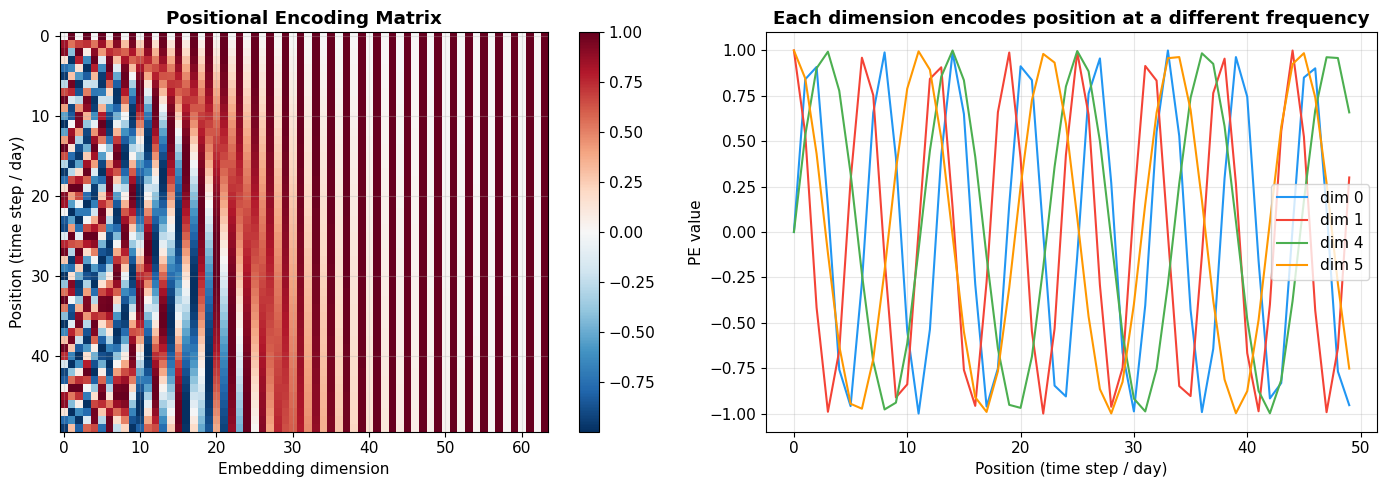

Low dimensions = high frequency oscillation = distinguishes nearby positions
High dimensions = low frequency = captures long-range position differences

For stock data: position = trading day. The model knows "this is day 3" vs "day 30".


In [6]:
# Visualize positional encoding
def positional_encoding(max_len, d_model):
    pe = np.zeros((max_len, d_model))
    position = np.arange(max_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return pe

pe = positional_encoding(50, 64)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im = ax1.imshow(pe, cmap='RdBu_r', aspect='auto')
ax1.set_xlabel('Embedding dimension')
ax1.set_ylabel('Position (time step / day)')
ax1.set_title('Positional Encoding Matrix', fontweight='bold')
plt.colorbar(im, ax=ax1)

for i, color in zip([0, 1, 4, 5], [C_BLUE, C_RED, C_GREEN, C_ORANGE]):
    ax2.plot(pe[:, i], color=color, label=f'dim {i}', linewidth=1.5)
ax2.set_xlabel('Position (time step / day)')
ax2.set_ylabel('PE value')
ax2.set_title('Each dimension encodes position at a different frequency', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print('Low dimensions = high frequency oscillation = distinguishes nearby positions')
print('High dimensions = low frequency = captures long-range position differences')
print('\nFor stock data: position = trading day. The model knows "this is day 3" vs "day 30".')

In [7]:
# Architecture diagram as text visualization
print('='*60)
print('     STANDARD TRANSFORMER ENCODER (for reference)')
print('='*60)
print()
print('  Input: Stock features [batch, seq_len, d_input]')
print('    │')
print('    ▼')
print('  Linear Embedding: d_input → d_model')
print('    │')
print('    + Positional Encoding')
print('    │')
print('    ▼')
print('  ┌─────────────────────────────────┐')
print('  │  Encoder Layer (×N layers)       │')
print('  │                                  │')
print('  │  ┌──────────────────────────┐   │')
print('  │  │ Multi-Head Attention      │   │')
print('  │  │ softmax(QK^T / √d_k) V   │   │  ← FIXED temperature √d_k')
print('  │  └──────────────────────────┘   │')
print('  │  + Residual + LayerNorm          │')
print('  │                                  │')
print('  │  ┌──────────────────────────┐   │')
print('  │  │ Feed-Forward Network      │   │')
print('  │  │ ReLU(xW₁+b₁)W₂+b₂       │   │')
print('  │  └──────────────────────────┘   │')
print('  │  + Residual + LayerNorm          │')
print('  └─────────────────────────────────┘')
print('    │')
print('    ▼')
print('  Take last time step → Linear → Prediction')
print()
print('  TOTAL PARAMETERS (typical):')
print('  d_model=64, n_heads=4, n_layers=2, d_ff=256')
print(f'  Attention per layer: 4 × (64×64) = {4*64*64:,} params')
print(f'  FFN per layer: 64×256 + 256×64 = {64*256 + 256*64:,} params')

     STANDARD TRANSFORMER ENCODER (for reference)

  Input: Stock features [batch, seq_len, d_input]
    │
    ▼
  Linear Embedding: d_input → d_model
    │
    + Positional Encoding
    │
    ▼
  ┌─────────────────────────────────┐
  │  Encoder Layer (×N layers)       │
  │                                  │
  │  ┌──────────────────────────┐   │
  │  │ Multi-Head Attention      │   │
  │  │ softmax(QK^T / √d_k) V   │   │  ← FIXED temperature √d_k
  │  └──────────────────────────┘   │
  │  + Residual + LayerNorm          │
  │                                  │
  │  ┌──────────────────────────┐   │
  │  │ Feed-Forward Network      │   │
  │  │ ReLU(xW₁+b₁)W₂+b₂       │   │
  │  └──────────────────────────┘   │
  │  + Residual + LayerNorm          │
  └─────────────────────────────────┘
    │
    ▼
  Take last time step → Linear → Prediction

  TOTAL PARAMETERS (typical):
  d_model=64, n_heads=4, n_layers=2, d_ff=256
  Attention per layer: 4 × (64×64) = 16,384 params
  FFN per layer: 64

---
# Part 5: Transformers for Financial Time Series

## How stock data becomes Transformer input

### Raw data (one stock, T days)
Each day has features: Open, High, Low, Close, Volume, ...

### Sliding window approach
We take a window of $L$ days (e.g., 60 trading days ≈ 3 months) to predict the next day's return.

```
Day:    1   2   3   ... 58  59  60  | 61 (target)
         └──────── input window ─────┘   └─ predict
```

### Feature engineering (typical)
| Feature | Description | Formula |
|---------|-------------|---------|
| Return | Daily log return | $r_t = \ln(P_t / P_{t-1})$ |
| MA(k) | Moving average | $\frac{1}{k}\sum_{i=0}^{k-1} P_{t-i}$ |
| RSI | Relative strength index | Momentum indicator |
| Volatility(k) | Rolling std of returns | $\sigma_t^{(k)} = \text{std}(r_{t-k+1}, ..., r_t)$ |
| Volume ratio | Relative volume | $V_t / \text{MA}(V, 20)$ |

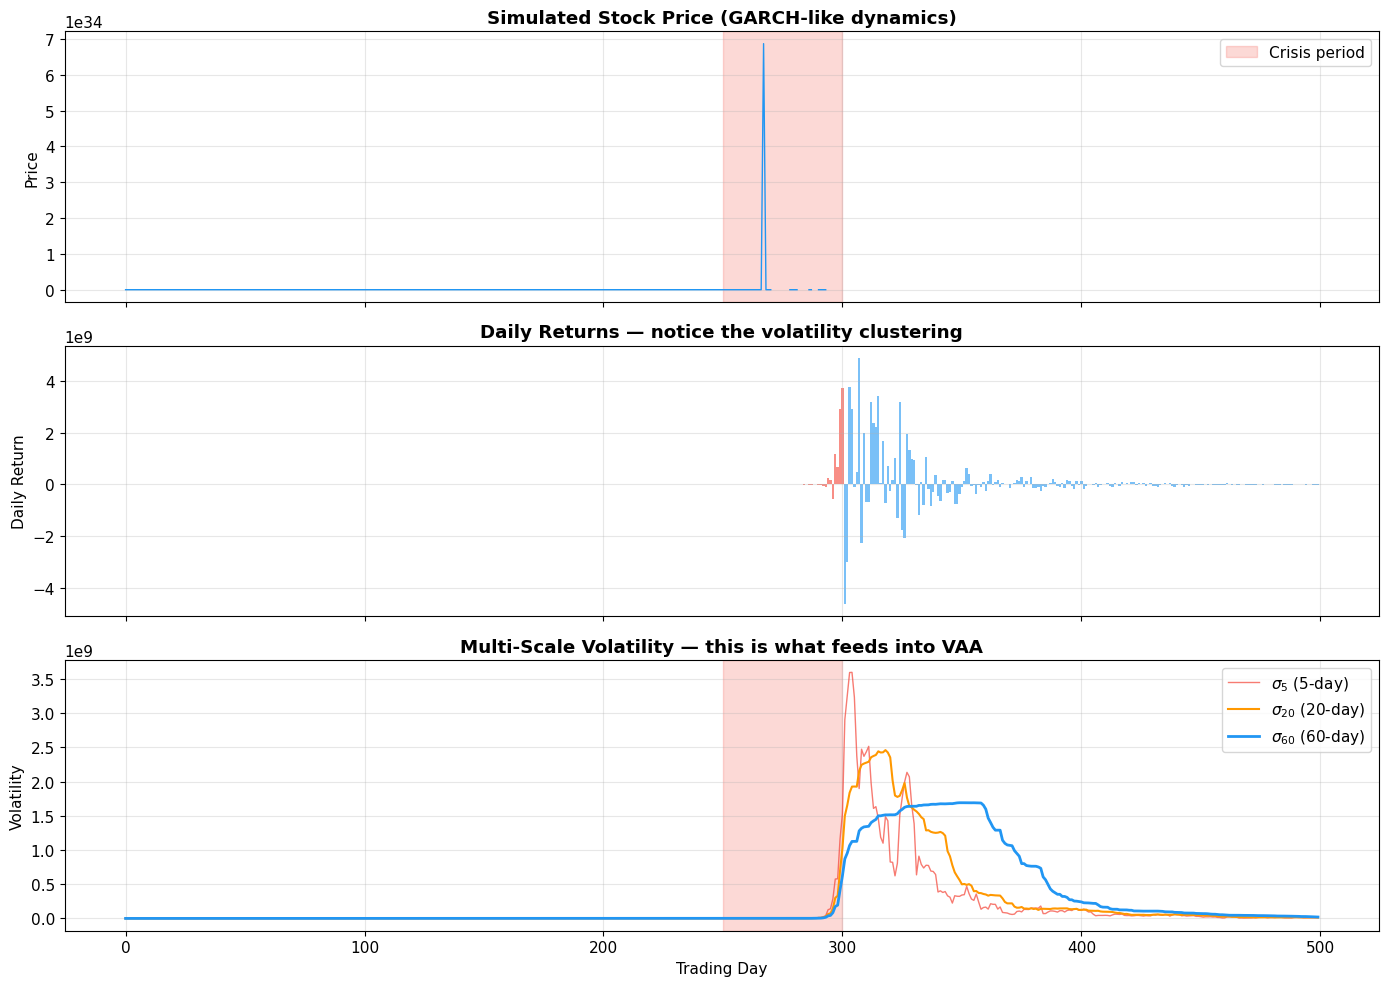

Key observations:
1. Volatility CLUSTERS — high-vol days follow high-vol days (GARCH effect)
2. Different time scales capture different information:
   σ_5  = reactive, noisy, captures sudden regime shifts quickly
   σ_60 = smooth, stable, captures the overall volatility regime
3. During crisis (day 250-300): ALL scales spike, but at different speeds


In [8]:
# Simulate realistic stock data to demonstrate the pipeline
np.random.seed(42)
T = 500  # trading days

# Generate price with regime changes
returns = np.zeros(T)
volatility_true = np.zeros(T)

# Simulate GARCH-like behavior
omega, alpha, beta = 0.00001, 0.1, 0.85
sigma2 = 0.0002  # initial variance

for t in range(1, T):
    sigma2 = omega + alpha * returns[t-1]**2 + beta * sigma2
    # Add a regime shift (crisis) around day 250-300
    if 250 <= t <= 300:
        sigma2 *= 3  # crisis amplification
    volatility_true[t] = np.sqrt(sigma2)
    returns[t] = np.random.normal(0.0003, np.sqrt(sigma2))  # small positive drift

prices = 100 * np.exp(np.cumsum(returns))

# Compute features
vol_5 = np.array([np.std(returns[max(0,i-4):i+1]) for i in range(T)])
vol_20 = np.array([np.std(returns[max(0,i-19):i+1]) for i in range(T)])
vol_60 = np.array([np.std(returns[max(0,i-59):i+1]) for i in range(T)])

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price
axes[0].plot(prices, color=C_BLUE, linewidth=1)
axes[0].axvspan(250, 300, alpha=0.2, color=C_RED, label='Crisis period')
axes[0].set_ylabel('Price')
axes[0].set_title('Simulated Stock Price (GARCH-like dynamics)', fontweight='bold')
axes[0].legend()

# Returns
colors_ret = [C_RED if 250 <= i <= 300 else C_BLUE for i in range(T)]
axes[1].bar(range(T), returns, color=colors_ret, alpha=0.6, width=1)
axes[1].set_ylabel('Daily Return')
axes[1].set_title('Daily Returns — notice the volatility clustering', fontweight='bold')

# Multi-scale volatility
axes[2].plot(vol_5, color=C_RED, alpha=0.7, linewidth=1, label='$\sigma_5$ (5-day)')
axes[2].plot(vol_20, color=C_ORANGE, linewidth=1.5, label='$\sigma_{20}$ (20-day)')
axes[2].plot(vol_60, color=C_BLUE, linewidth=2, label='$\sigma_{60}$ (60-day)')
axes[2].axvspan(250, 300, alpha=0.2, color=C_RED)
axes[2].set_ylabel('Volatility')
axes[2].set_xlabel('Trading Day')
axes[2].set_title('Multi-Scale Volatility — this is what feeds into VAA', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

print('Key observations:')
print('1. Volatility CLUSTERS — high-vol days follow high-vol days (GARCH effect)')
print('2. Different time scales capture different information:')
print('   σ_5  = reactive, noisy, captures sudden regime shifts quickly')
print('   σ_60 = smooth, stable, captures the overall volatility regime')
print('3. During crisis (day 250-300): ALL scales spike, but at different speeds')

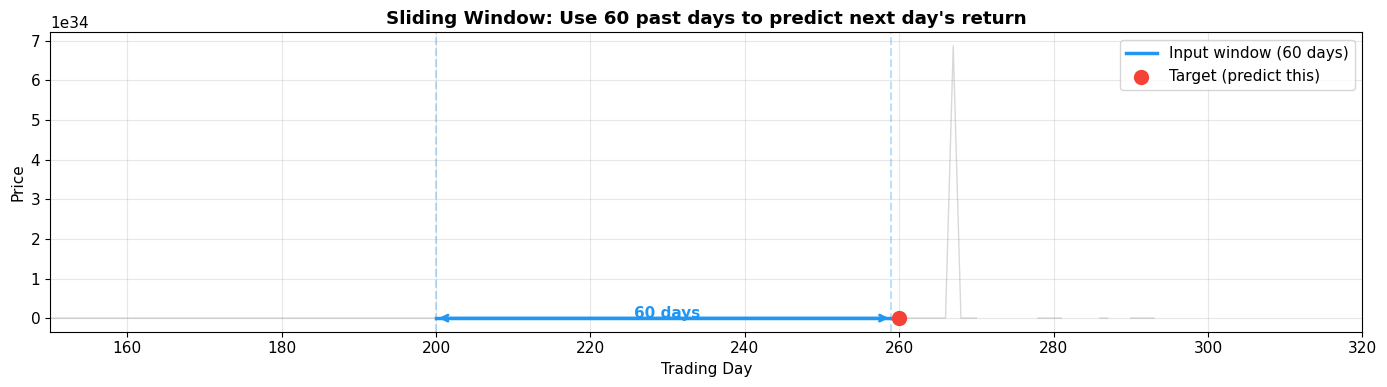

Transformer input shape: [batch_size, 60, n_features]
Transformer output: scalar (predicted return for day 260)


In [9]:
# Show the sliding window approach
window_size = 60
start = 200

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(T), prices, color='gray', alpha=0.3, linewidth=1)

# Highlight input window
ax.plot(range(start, start + window_size), 
        prices[start:start + window_size], 
        color=C_BLUE, linewidth=2.5, label=f'Input window ({window_size} days)')

# Highlight target
ax.scatter([start + window_size], [prices[start + window_size]], 
           color=C_RED, s=100, zorder=5, label='Target (predict this)')

ax.axvline(start, color=C_BLUE, linestyle='--', alpha=0.3)
ax.axvline(start + window_size - 1, color=C_BLUE, linestyle='--', alpha=0.3)

ax.annotate('', xy=(start, prices[start] - 2), xytext=(start + window_size - 1, prices[start] - 2),
            arrowprops=dict(arrowstyle='<->', color=C_BLUE, lw=2))
ax.text(start + window_size//2, prices[start] - 3, f'{window_size} days', 
        ha='center', color=C_BLUE, fontweight='bold')

ax.set_xlabel('Trading Day')
ax.set_ylabel('Price')
ax.set_title('Sliding Window: Use 60 past days to predict next day\'s return', fontweight='bold')
ax.legend()
ax.set_xlim(150, 320)
plt.tight_layout()
plt.show()

print(f'Transformer input shape: [batch_size, {window_size}, n_features]')
print(f'Transformer output: scalar (predicted return for day {start + window_size})')

---
# Part 6: Volatility & GARCH

## What is volatility?

**Volatility** = the standard deviation of returns. It measures **how much prices fluctuate**.

- High volatility → large price swings → uncertain market
- Low volatility → small price swings → calm market

### Key "stylized facts" of financial volatility

1. **Volatility clustering**: High-vol days tend to follow high-vol days
2. **Mean reversion**: Volatility eventually returns to a long-run average
3. **Leverage effect**: Negative returns increase volatility more than positive returns of the same magnitude

## GARCH(1,1) Model

The workhorse of volatility modeling:

$$\sigma_t^2 = \omega + \alpha \cdot \epsilon_{t-1}^2 + \beta \cdot \sigma_{t-1}^2$$

Where:
- $\sigma_t^2$ = conditional variance (predicted volatility) at time $t$
- $\epsilon_{t-1}^2$ = squared return (surprise) from yesterday
- $\omega$ = long-run variance base level
- $\alpha$ = reaction to news (how much yesterday's surprise matters)
- $\beta$ = persistence (how much yesterday's volatility carries over)
- Constraint: $\alpha + \beta < 1$ for stationarity

### Intuition
Tomorrow's volatility = **base level** + **reaction to today's shock** + **memory of today's volatility**

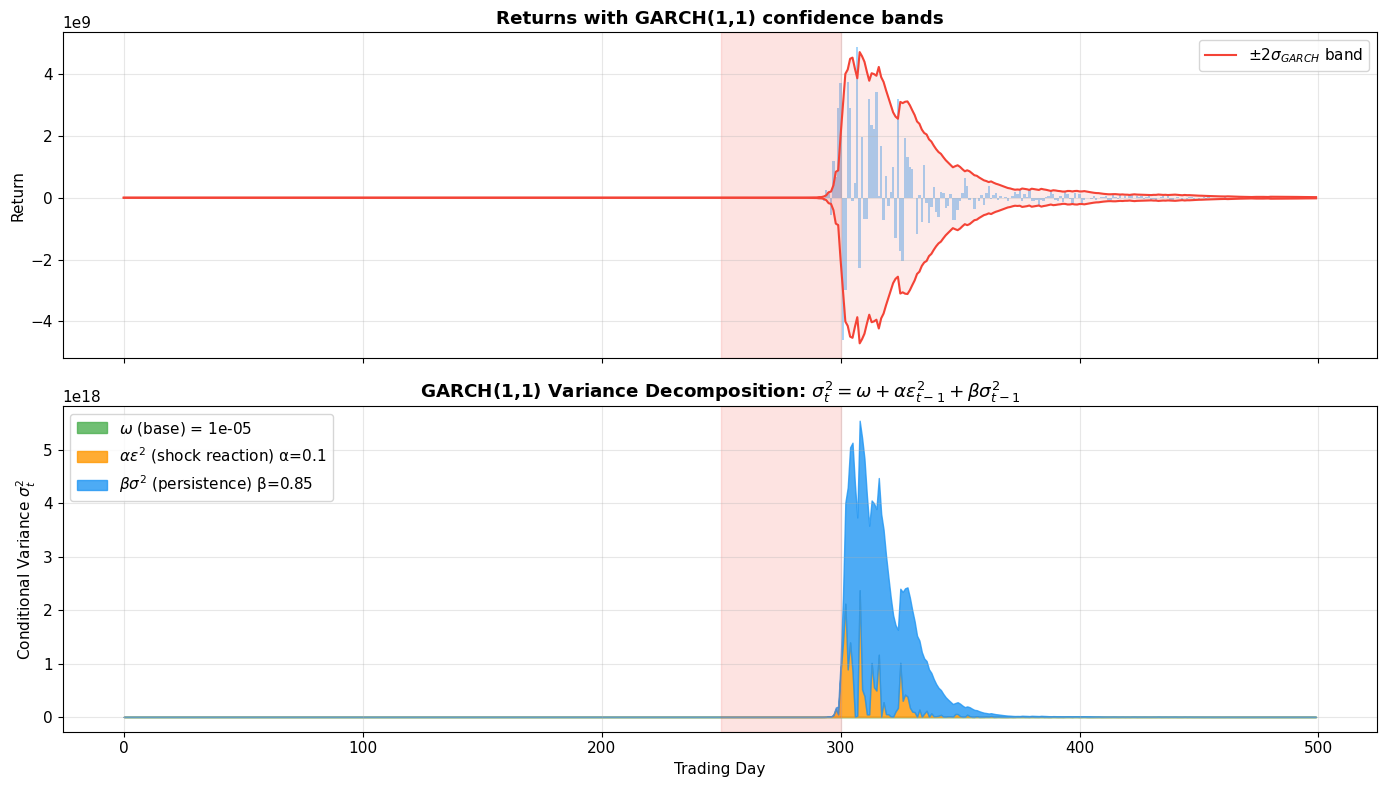

GARCH persistence: α + β = 0.95 (high = slow decay of volatility)
Long-run variance: ω/(1-α-β) = 0.000200
Long-run volatility: 0.0141 (1.41%)

Notice: β (persistence) dominates — volatility is "sticky"
This is why volatility clusters!


In [10]:
# GARCH(1,1) step-by-step visualization

omega, alpha, beta = 0.00001, 0.10, 0.85

# Use our simulated returns
garch_var = np.zeros(T)
garch_var[0] = np.var(returns[:20])  # initialize with sample variance

for t in range(1, T):
    garch_var[t] = omega + alpha * returns[t-1]**2 + beta * garch_var[t-1]

garch_vol = np.sqrt(garch_var)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Returns with GARCH bands
axes[0].bar(range(T), returns, color=C_BLUE, alpha=0.4, width=1)
axes[0].plot(2 * garch_vol, color=C_RED, linewidth=1.5, label='$\pm 2\sigma_{GARCH}$ band')
axes[0].plot(-2 * garch_vol, color=C_RED, linewidth=1.5)
axes[0].fill_between(range(T), -2*garch_vol, 2*garch_vol, alpha=0.1, color=C_RED)
axes[0].set_ylabel('Return')
axes[0].set_title('Returns with GARCH(1,1) confidence bands', fontweight='bold')
axes[0].legend()
axes[0].axvspan(250, 300, alpha=0.15, color=C_RED)

# GARCH variance decomposition
base = np.full(T, omega)
shock = alpha * np.roll(returns, 1)**2
shock[0] = 0
persistence = beta * np.roll(garch_var, 1)
persistence[0] = 0

axes[1].fill_between(range(T), 0, base, alpha=0.8, color=C_GREEN, label=f'$\omega$ (base) = {omega}')
axes[1].fill_between(range(T), base, base + shock, alpha=0.8, color=C_ORANGE, label=f'$\\alpha \\epsilon^2$ (shock reaction) α={alpha}')
axes[1].fill_between(range(T), base + shock, base + shock + persistence, alpha=0.8, color=C_BLUE, label=f'$\\beta \\sigma^2$ (persistence) β={beta}')
axes[1].set_ylabel('Conditional Variance $\sigma^2_t$')
axes[1].set_xlabel('Trading Day')
axes[1].set_title('GARCH(1,1) Variance Decomposition: $\sigma^2_t = \omega + \\alpha\epsilon^2_{t-1} + \\beta\sigma^2_{t-1}$', fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].axvspan(250, 300, alpha=0.15, color=C_RED)

plt.tight_layout()
plt.show()

print(f'GARCH persistence: α + β = {alpha + beta:.2f} (high = slow decay of volatility)')
print(f'Long-run variance: ω/(1-α-β) = {omega/(1-alpha-beta):.6f}')
print(f'Long-run volatility: {np.sqrt(omega/(1-alpha-beta)):.4f} ({np.sqrt(omega/(1-alpha-beta))*100:.2f}%)')
print(f'\nNotice: β (persistence) dominates — volatility is "sticky"')
print(f'This is why volatility clusters!')

---
# Part 7: Existing Approaches — What Has Been Done

The literature has explored three dimensions of combining GARCH/volatility with neural networks:

## Dimension 1: GARCH in Architecture (Zhao et al. AAAI 2024)
**GARCH-LSTM**: Proved GARCH(1,1) ↔ a specific form of RNN. Then built GARCH-LSTM by replacing the LSTM output gate with GARCH's volatility computation.

```
LSTM hidden state → forget gate, input gate → cell state
                                                  ↓
                                        GARCH formula (replaces output gate)
                                                  ↓
                                            σ²_t prediction
```
**Target**: Predict volatility (σ²)

## Dimension 2: GARCH in Loss Function (Xu et al. ICAIF 2024)
**GINN**: Standard LSTM architecture, but the loss function includes a GARCH-informed term:

$$\text{Loss} = \lambda \cdot \text{MSE}(\sigma^2_{true}, \hat\sigma^2_{GINN}) + (1-\lambda) \cdot \text{MSE}(\hat\sigma^2_{GARCH}, \hat\sigma^2_{GINN})$$

The second term forces the NN to stay "close" to GARCH's predictions, acting as a regularizer.

**Target**: Predict volatility (σ²)

## Dimension 3: Volatility as Feature Branch (Chen et al. Entropy 2025)
**EMAT**: Multi-Aspect Attention Transformer with 3 enhancement components on a base attention:

```
Base Attention (content-aware gating)
    + Temporal Decay Enhancement (time-weighted attention)
    + Trend Enhancement (trend-gated attention)
    + Volatility Enhancement (volatility-gated attention)
    → Weighted fusion → Output
```

Volatility is one of several feature-gating branches, applied additively.

**Target**: Predict price

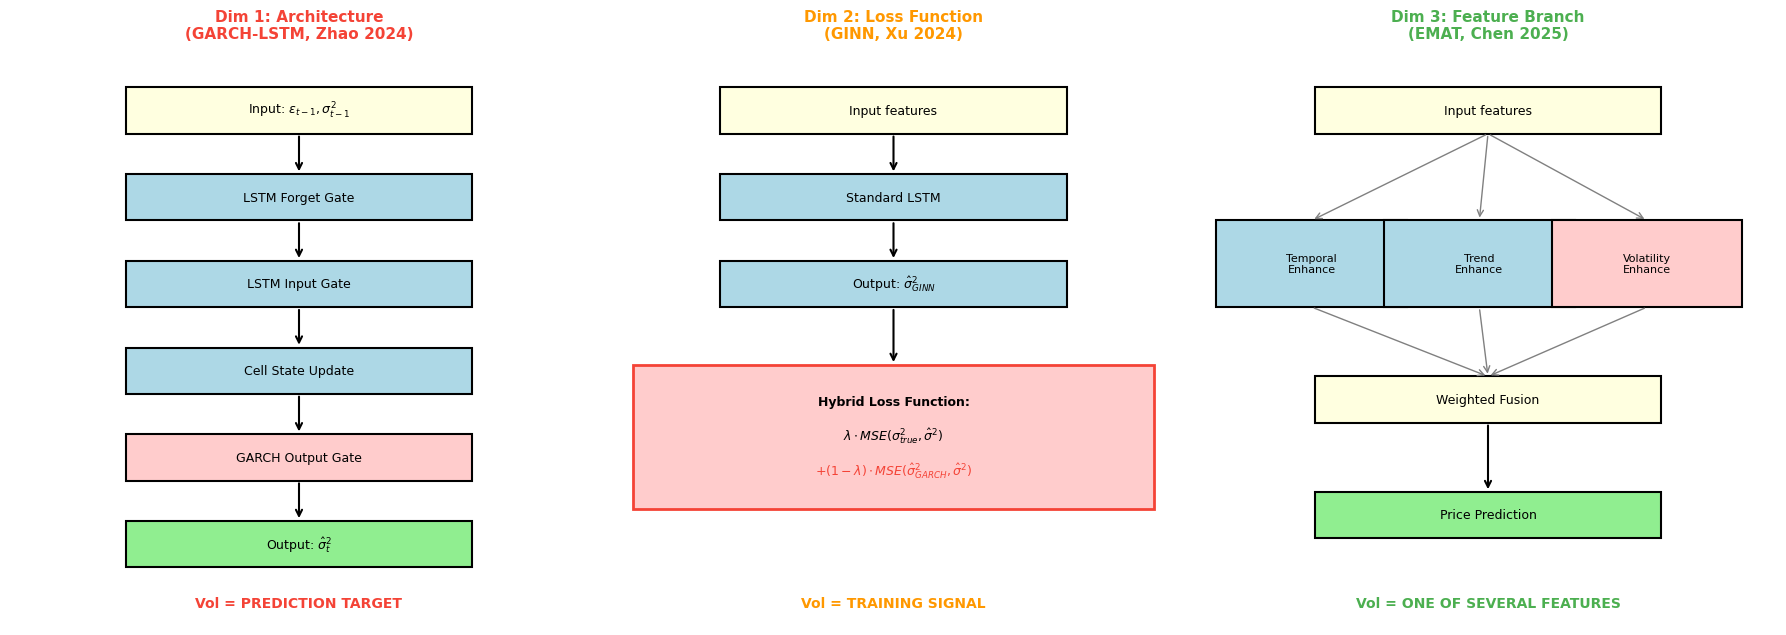

Summary of what exists:
  Dim 1 (Architecture):  GARCH replaces part of the NN structure
  Dim 2 (Loss):          GARCH constrains the training objective
  Dim 3 (Feature):       Volatility is one input feature branch among several

What is MISSING: volatility controlling the MECHANISM of attention itself
  → This is our Dimension 4: GARCH in Attention Temperature


In [11]:
# Visual comparison of the three existing dimensions

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Dimension 1: GARCH in Architecture
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Dim 1: Architecture\n(GARCH-LSTM, Zhao 2024)', fontweight='bold', fontsize=11, color=C_RED)

boxes_1 = [
    (2, 8.5, 6, 0.8, 'Input: $\epsilon_{t-1}, \sigma^2_{t-1}$', 'lightyellow'),
    (2, 7.0, 6, 0.8, 'LSTM Forget Gate', 'lightblue'),
    (2, 5.5, 6, 0.8, 'LSTM Input Gate', 'lightblue'),
    (2, 4.0, 6, 0.8, 'Cell State Update', 'lightblue'),
    (2, 2.5, 6, 0.8, 'GARCH Output Gate', '#ffcccc'),
    (2, 1.0, 6, 0.8, 'Output: $\hat{\sigma}^2_t$', 'lightgreen'),
]
for x, y, w, h, text, color in boxes_1:
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='black', linewidth=1.5))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=9)
for i in range(len(boxes_1)-1):
    ax.annotate('', xy=(5, boxes_1[i+1][1]+0.8), xytext=(5, boxes_1[i][1]),
               arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(5, 0.3, 'Vol = PREDICTION TARGET', ha='center', fontweight='bold', color=C_RED, fontsize=10)

# Dimension 2: GARCH in Loss
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Dim 2: Loss Function\n(GINN, Xu 2024)', fontweight='bold', fontsize=11, color=C_ORANGE)

boxes_2 = [
    (2, 8.5, 6, 0.8, 'Input features', 'lightyellow'),
    (2, 7.0, 6, 0.8, 'Standard LSTM', 'lightblue'),
    (2, 5.5, 6, 0.8, 'Output: $\hat{\sigma}^2_{GINN}$', 'lightblue'),
]
for x, y, w, h, text, color in boxes_2:
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='black', linewidth=1.5))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=9)
for i in range(len(boxes_2)-1):
    ax.annotate('', xy=(5, boxes_2[i+1][1]+0.8), xytext=(5, boxes_2[i][1]),
               arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Loss function box
ax.add_patch(plt.Rectangle((0.5, 2.0, 9, 2.5), width=9, height=2.5, facecolor='#ffcccc', edgecolor=C_RED, linewidth=2))
ax.text(5, 3.8, 'Hybrid Loss Function:', ha='center', fontweight='bold', fontsize=9)
ax.text(5, 3.2, '$\lambda \cdot MSE(\sigma^2_{true}, \hat{\sigma}^2)$', ha='center', fontsize=9)
ax.text(5, 2.6, '$+ (1-\lambda) \cdot MSE(\hat{\sigma}^2_{GARCH}, \hat{\sigma}^2)$', ha='center', fontsize=9, color=C_RED)
ax.annotate('', xy=(5, 4.5), xytext=(5, 5.5),
           arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(5, 0.3, 'Vol = TRAINING SIGNAL', ha='center', fontweight='bold', color=C_ORANGE, fontsize=10)

# Dimension 3: Volatility as Feature Branch (EMAT)
ax = axes[2]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Dim 3: Feature Branch\n(EMAT, Chen 2025)', fontweight='bold', fontsize=11, color=C_GREEN)

ax.add_patch(plt.Rectangle((2, 8.5), 6, 0.8, facecolor='lightyellow', edgecolor='black', linewidth=1.5))
ax.text(5, 8.9, 'Input features', ha='center', va='center', fontsize=9)

# Three parallel branches
branch_data = [
    (0.3, 'Temporal\nEnhance', 'lightblue'),
    (3.2, 'Trend\nEnhance', 'lightblue'),
    (6.1, 'Volatility\nEnhance', '#ffcccc'),
]
for x, text, color in branch_data:
    ax.add_patch(plt.Rectangle((x, 5.5), 3.3, 1.5, facecolor=color, edgecolor='black', linewidth=1.5))
    ax.text(x + 1.65, 6.25, text, ha='center', va='center', fontsize=8)

ax.add_patch(plt.Rectangle((2, 3.5), 6, 0.8, facecolor='lightyellow', edgecolor='black', linewidth=1.5))
ax.text(5, 3.9, 'Weighted Fusion', ha='center', va='center', fontsize=9)

ax.add_patch(plt.Rectangle((2, 1.5), 6, 0.8, facecolor='lightgreen', edgecolor='black', linewidth=1.5))
ax.text(5, 1.9, 'Price Prediction', ha='center', va='center', fontsize=9)

for bx, _, _ in branch_data:
    ax.annotate('', xy=(bx + 1.65, 7.0), xytext=(5, 8.5),
               arrowprops=dict(arrowstyle='->', color='gray', lw=1))
    ax.annotate('', xy=(5, 4.3), xytext=(bx + 1.65, 5.5),
               arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax.annotate('', xy=(5, 2.3), xytext=(5, 3.5),
           arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax.text(5, 0.3, 'Vol = ONE OF SEVERAL FEATURES', ha='center', fontweight='bold', color=C_GREEN, fontsize=10)

plt.tight_layout()
plt.show()

print('Summary of what exists:')
print('  Dim 1 (Architecture):  GARCH replaces part of the NN structure')
print('  Dim 2 (Loss):          GARCH constrains the training objective')
print('  Dim 3 (Feature):       Volatility is one input feature branch among several')
print()
print('What is MISSING: volatility controlling the MECHANISM of attention itself')
print('  → This is our Dimension 4: GARCH in Attention Temperature')

---
# Part 8: Our Innovation — Volatility-Aware Attention (VAA)

## The Key Insight

We don't change the architecture. We don't change the loss function. We don't add volatility as a feature branch.

We change **how attention distributes its focus**, by making the softmax temperature a function of current market volatility.

### Standard Transformer
$$\text{Attention} = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

### VAA Transformer
$$\text{Attention} = \text{softmax}\left(\frac{QK^T}{\tau_h(\sigma)}\right) V$$

Where the temperature for each head $h$ is:
$$\tau_h(\sigma) = \sqrt{d_k} \cdot s_h$$
$$\mathbf{s} = s_{min} + (s_{max} - s_{min}) \cdot \text{sigmoid}(\text{MLP}([\sigma_5, \sigma_{10}, \sigma_{20}, \sigma_{60}]))$$

- Input: 4 multi-scale volatilities (5, 10, 20, 60-day rolling windows)
- MLP: Linear(4→16) → ReLU → Linear(16→n_heads) → Sigmoid
- Output: one scaling factor per head, bounded in $[s_{min}, s_{max}]$ = $[0.5, 2.0]$
- Final temperature = $\sqrt{d_k} \times s_h$

### What changes at inference time

| Market State | Multi-scale σ | s_h values | Temperature | Attention |
|:---:|:---:|:---:|:---:|:---:|
| Calm | All low | → ~0.5 | 0.5 × √d_k (smaller) | **Sharp** (focused) |
| Crisis | All high | → ~2.0 | 2.0 × √d_k (larger) | **Flat** (spread) |
| Transitional | Mixed | → ~1.0 | 1.0 × √d_k (standard) | **Balanced** |

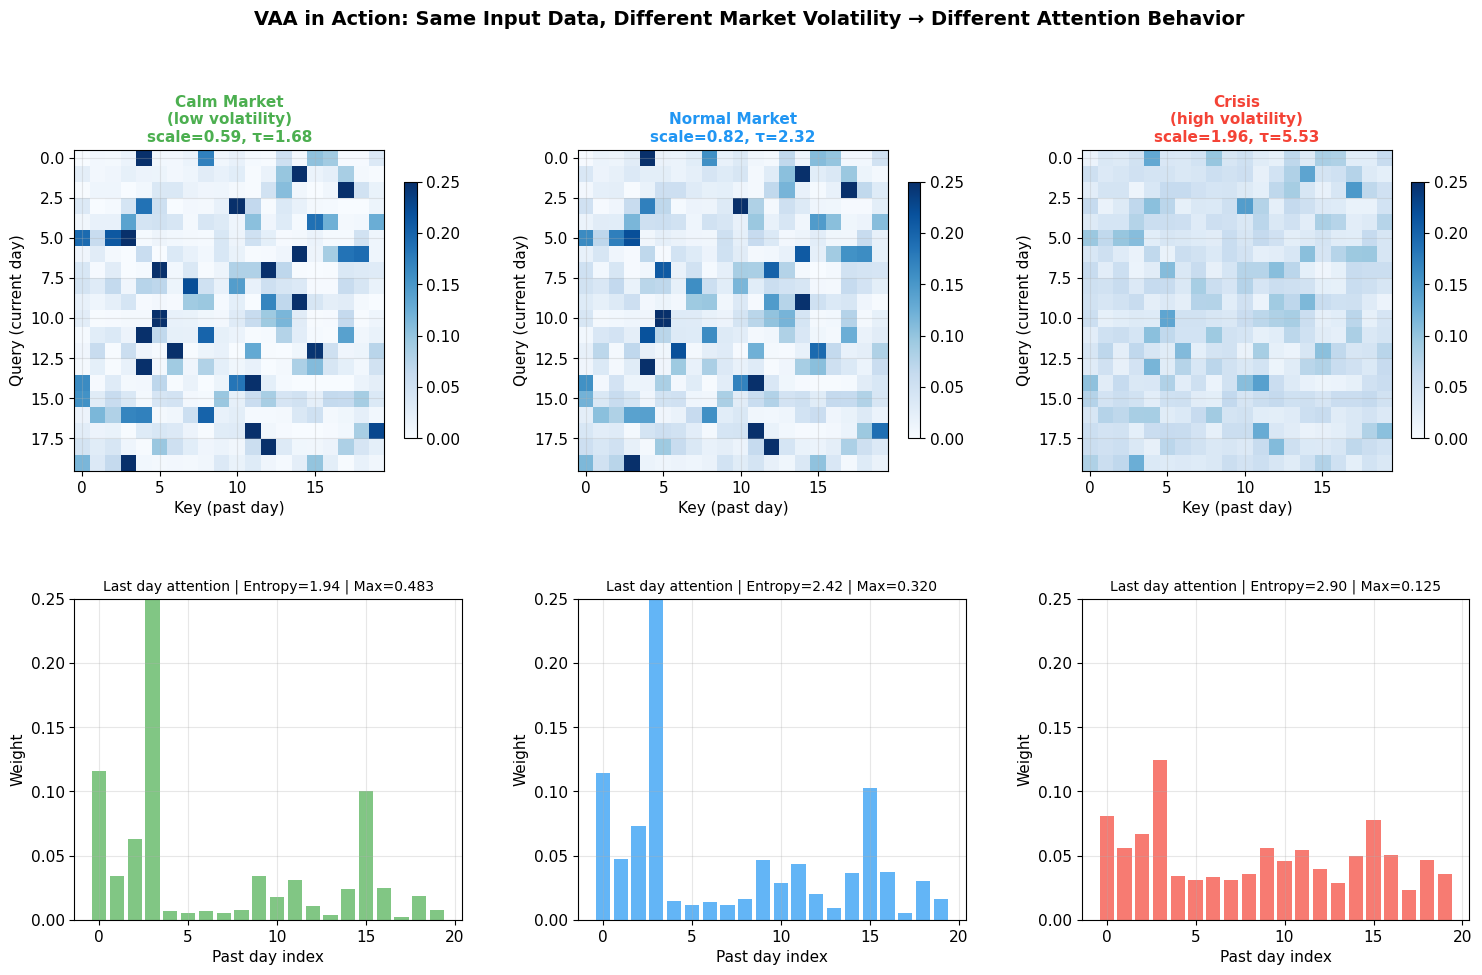

LEFT (Calm):   Low vol → low temperature → SHARP attention → model focuses on key days
MIDDLE:        Normal vol → standard temperature → balanced attention
RIGHT (Crisis): High vol → high temperature → FLAT attention → model spreads focus broadly

The SAME input data produces DIFFERENT attention patterns based on market conditions!
This is what no prior work does.


In [12]:
# THE CORE DEMO: Show how VAA changes attention in different market regimes

# Simulate attention scores (fixed — same "content")
np.random.seed(123)
seq_len_demo = 20
d_k_demo = 8
Q_demo = np.random.randn(seq_len_demo, d_k_demo)
K_demo = np.random.randn(seq_len_demo, d_k_demo)
raw_scores_demo = Q_demo @ K_demo.T

# Three market regimes
regimes = [
    {'name': 'Calm Market\n(low volatility)',   'vol': [0.005, 0.006, 0.007, 0.008], 'color': C_GREEN},
    {'name': 'Normal Market',                    'vol': [0.015, 0.014, 0.013, 0.012], 'color': C_BLUE},
    {'name': 'Crisis\n(high volatility)',        'vol': [0.045, 0.040, 0.035, 0.030], 'color': C_RED},
]

# Simulate the MLP mapping (simplified but realistic)
def simulate_vol_to_scale(vol_features, scale_min=0.5, scale_max=2.0):
    """Simplified version of the vol_net MLP."""
    # Higher volatility → higher sigmoid input → higher scale → higher temperature
    vol_mean = np.mean(vol_features)
    # Normalize: typical vol range 0.005-0.05, map to roughly -3 to +3 for sigmoid
    z = (vol_mean - 0.02) / 0.01 * 2  
    sigmoid_out = 1 / (1 + np.exp(-z))
    scale = scale_min + (scale_max - scale_min) * sigmoid_out
    return scale

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.3)

query_idx = seq_len_demo - 1  # last position

for col, regime in enumerate(regimes):
    scale = simulate_vol_to_scale(regime['vol'])
    temperature = np.sqrt(d_k_demo) * scale
    
    # Attention weights for all positions
    attn_map = softmax(raw_scores_demo / temperature)
    
    # Top row: attention heatmap
    ax_top = fig.add_subplot(gs[0, col])
    im = ax_top.imshow(attn_map, cmap='Blues', aspect='auto', vmin=0, vmax=0.25)
    ax_top.set_title(f'{regime["name"]}\nscale={scale:.2f}, τ={temperature:.2f}', 
                     fontweight='bold', color=regime['color'], fontsize=11)
    ax_top.set_xlabel('Key (past day)')
    ax_top.set_ylabel('Query (current day)')
    plt.colorbar(im, ax=ax_top, shrink=0.8)
    
    # Bottom row: bar chart for the last position
    ax_bot = fig.add_subplot(gs[1, col])
    w = attn_map[query_idx]
    bars = ax_bot.bar(range(seq_len_demo), w, color=regime['color'], alpha=0.7)
    
    entropy = -np.sum(w * np.log(w + 1e-10))
    ax_bot.set_title(f'Last day attention | Entropy={entropy:.2f} | Max={np.max(w):.3f}', fontsize=10)
    ax_bot.set_xlabel('Past day index')
    ax_bot.set_ylabel('Weight')
    ax_bot.set_ylim(0, 0.25)

fig.suptitle('VAA in Action: Same Input Data, Different Market Volatility → Different Attention Behavior',
             fontweight='bold', fontsize=14, y=1.02)
plt.show()

print('LEFT (Calm):   Low vol → low temperature → SHARP attention → model focuses on key days')
print('MIDDLE:        Normal vol → standard temperature → balanced attention')
print('RIGHT (Crisis): High vol → high temperature → FLAT attention → model spreads focus broadly')
print()
print('The SAME input data produces DIFFERENT attention patterns based on market conditions!')
print('This is what no prior work does.')

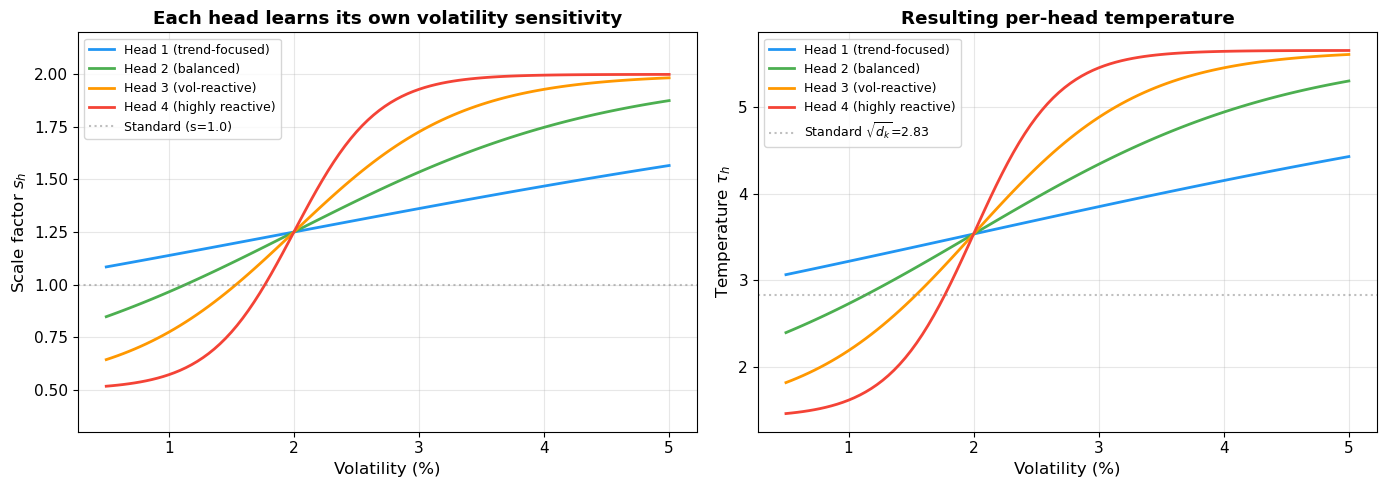

WHY per-head matters:
  Head 1: barely reacts to volatility → always sharp → captures persistent trends
  Head 4: highly reactive → flattens quickly in crisis → captures regime-dependent patterns
  The model LEARNS which heads should be sensitive to volatility!

This is richer than EMAT (which uses a single volatility gate for all attention).


In [13]:
# Per-head behavior: different heads can respond differently to the same volatility

np.random.seed(42)
n_heads = 4

# Simulate learned MLP weights for 4 heads
# Each head has different sensitivity to volatility
head_sensitivities = [0.3, 0.8, 1.5, 3.0]  # how reactive each head is
head_names = ['Head 1\n(trend-focused)', 'Head 2\n(balanced)', 
              'Head 3\n(vol-reactive)', 'Head 4\n(highly reactive)']

vol_range = np.linspace(0.005, 0.05, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_h = [C_BLUE, C_GREEN, C_ORANGE, C_RED]

for i, (sens, name, color) in enumerate(zip(head_sensitivities, head_names, colors_h)):
    z = (vol_range - 0.02) / 0.01 * sens
    sigmoid_out = 1 / (1 + np.exp(-z))
    scales = 0.5 + (2.0 - 0.5) * sigmoid_out
    temps = np.sqrt(d_k_demo) * scales
    
    ax1.plot(vol_range * 100, scales, color=color, linewidth=2, label=name.replace('\n', ' '))
    ax2.plot(vol_range * 100, temps, color=color, linewidth=2, label=name.replace('\n', ' '))

ax1.axhline(1.0, color='gray', linestyle=':', alpha=0.5, label='Standard (s=1.0)')
ax1.set_xlabel('Volatility (%)', fontsize=12)
ax1.set_ylabel('Scale factor $s_h$', fontsize=12)
ax1.set_title('Each head learns its own volatility sensitivity', fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim(0.3, 2.2)

ax2.axhline(np.sqrt(d_k_demo), color='gray', linestyle=':', alpha=0.5, label=f'Standard $\\sqrt{{d_k}}$={np.sqrt(d_k_demo):.2f}')
ax2.set_xlabel('Volatility (%)', fontsize=12)
ax2.set_ylabel('Temperature $\\tau_h$', fontsize=12)
ax2.set_title('Resulting per-head temperature', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('WHY per-head matters:')
print('  Head 1: barely reacts to volatility → always sharp → captures persistent trends')
print('  Head 4: highly reactive → flattens quickly in crisis → captures regime-dependent patterns')
print('  The model LEARNS which heads should be sensitive to volatility!')
print('\nThis is richer than EMAT (which uses a single volatility gate for all attention).')

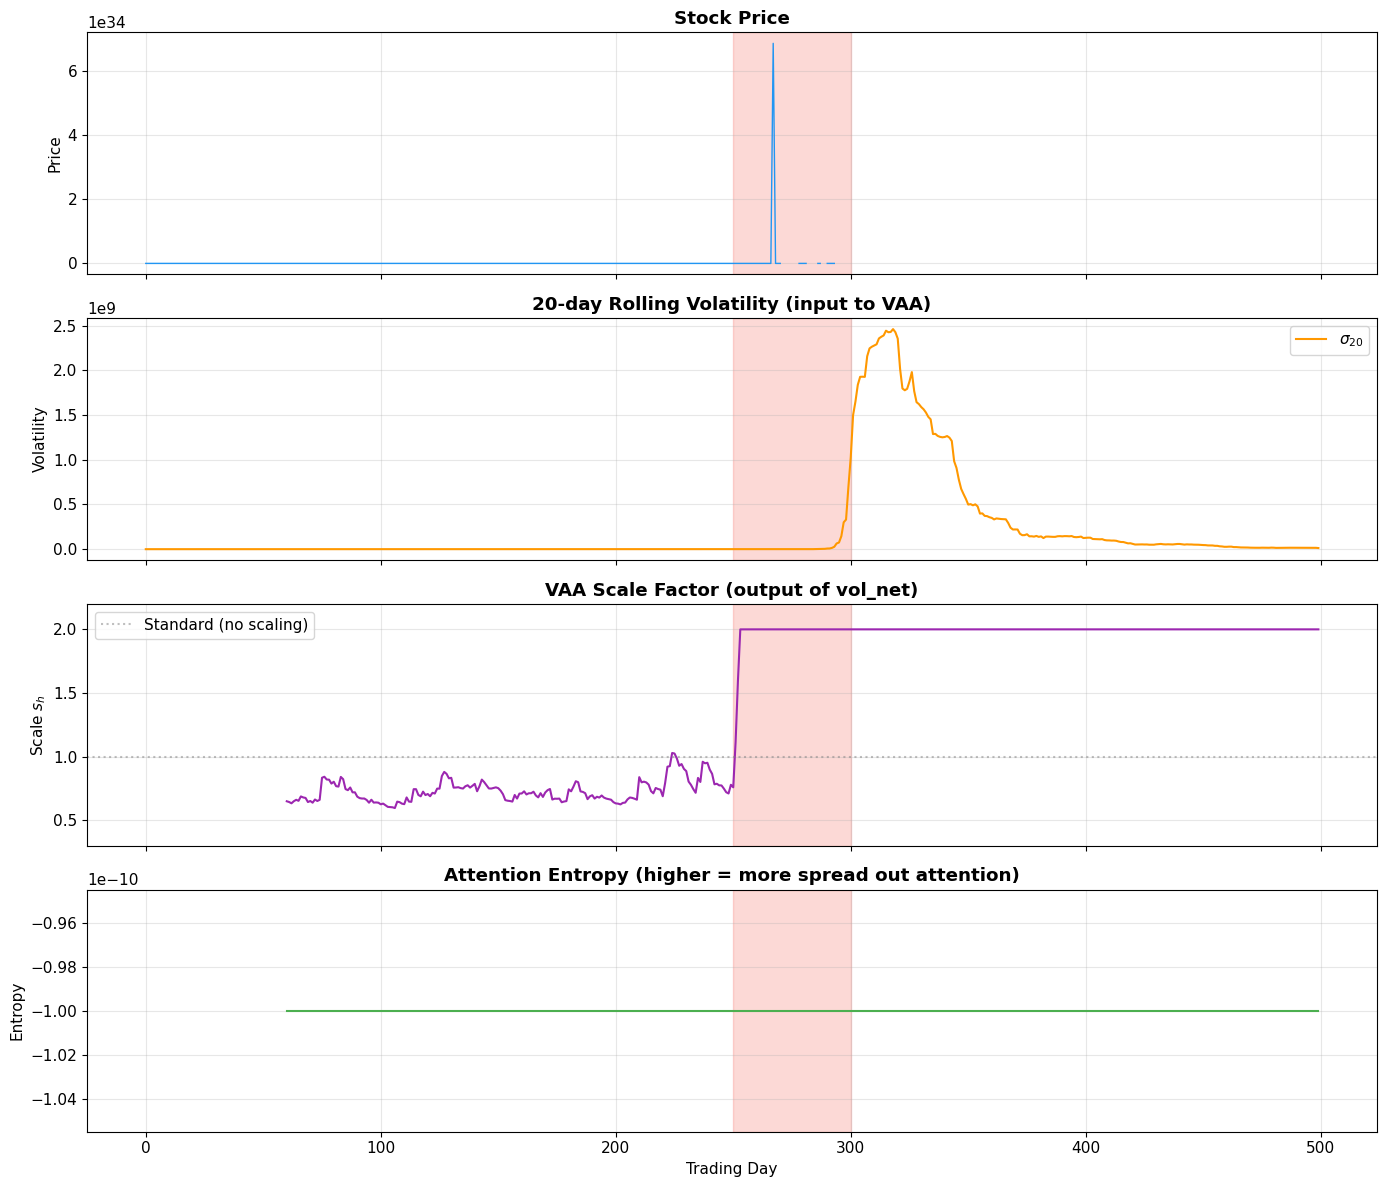

The full pipeline in action:
  Price moves → Volatility changes → VAA adjusts temperature → Attention reshapes

During crisis (red band):
  Volatility spikes → Scale rises toward 2.0 → Entropy increases → Attention flattens
After crisis:
  Volatility decays (GARCH persistence) → Scale drops → Attention sharpens again


In [14]:
# Show VAA on our simulated stock data across time

# For each time step, compute what VAA would do
start_idx = 60  # need 60 days of history
scales_over_time = []
entropies_over_time = []

vol_10 = np.array([np.std(returns[max(0,i-9):i+1]) for i in range(T)])

for t in range(start_idx, T):
    vol_features = [vol_5[t], vol_10[t], vol_20[t], vol_60[t]]
    s = simulate_vol_to_scale(vol_features)
    scales_over_time.append(s)
    
    # Compute entropy of attention at this temperature
    temp = np.sqrt(d_k_demo) * s
    w = softmax(raw_scores[0] / temp)  # use fixed scores for consistency
    ent = -np.sum(w * np.log(w + 1e-10))
    entropies_over_time.append(ent)

time_axis = np.arange(start_idx, T)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Price
axes[0].plot(prices, color=C_BLUE, linewidth=1)
axes[0].axvspan(250, 300, alpha=0.2, color=C_RED)
axes[0].set_ylabel('Price')
axes[0].set_title('Stock Price', fontweight='bold')

# Volatility
axes[1].plot(vol_20, color=C_ORANGE, linewidth=1.5, label='$\sigma_{20}$')
axes[1].axvspan(250, 300, alpha=0.2, color=C_RED)
axes[1].set_ylabel('Volatility')
axes[1].set_title('20-day Rolling Volatility (input to VAA)', fontweight='bold')
axes[1].legend()

# VAA scale factor
axes[2].plot(time_axis, scales_over_time, color=C_PURPLE, linewidth=1.5)
axes[2].axhline(1.0, color='gray', linestyle=':', alpha=0.5, label='Standard (no scaling)')
axes[2].axvspan(250, 300, alpha=0.2, color=C_RED)
axes[2].set_ylabel('Scale $s_h$')
axes[2].set_title('VAA Scale Factor (output of vol_net)', fontweight='bold')
axes[2].legend()
axes[2].set_ylim(0.3, 2.2)

# Attention entropy
axes[3].plot(time_axis, entropies_over_time, color=C_GREEN, linewidth=1.5)
axes[3].axvspan(250, 300, alpha=0.2, color=C_RED)
axes[3].set_ylabel('Entropy')
axes[3].set_xlabel('Trading Day')
axes[3].set_title('Attention Entropy (higher = more spread out attention)', fontweight='bold')

plt.tight_layout()
plt.show()

print('The full pipeline in action:')
print('  Price moves → Volatility changes → VAA adjusts temperature → Attention reshapes')
print()
print('During crisis (red band):')
print('  Volatility spikes → Scale rises toward 2.0 → Entropy increases → Attention flattens')
print('After crisis:')
print('  Volatility decays (GARCH persistence) → Scale drops → Attention sharpens again')

In [15]:
# The actual code architecture — annotated walkthrough

print('='*65)
print('     VAA TRANSFORMER ARCHITECTURE (actual code)')
print('='*65)
print()
print('  Input: Stock features [B, L, d_input]    e.g. [32, 60, 12]')
print('  Vol:   Volatility     [B, L, 4]          [σ_5, σ_10, σ_20, σ_60]')
print('    │')
print('    ▼')
print('  Linear Embedding: d_input → d_model')
print('    │')
print('    + Positional Encoding')
print('    │')
print('    ▼')
print('  ┌──────────────────────────────────────────┐')
print('  │  VAA Encoder Layer (×N layers)            │')
print('  │                                           │')
print('  │  ┌─────────────────────────────────────┐ │')
print('  │  │ Volatility-Aware Multi-Head Attn    │ │')
print('  │  │                                     │ │')
print('  │  │  vol_features[:, -1, :] ─┐          │ │  ← Use LAST timestep vol')
print('  │  │                          ▼          │ │')
print('  │  │              ┌──────────────┐       │ │')
print('  │  │              │ vol_net (MLP) │       │ │')
print('  │  │              │ 4→16→n_heads  │       │ │')
print('  │  │              │ + Sigmoid     │       │ │')
print('  │  │              └──────┬───────┘       │ │')
print('  │  │                     ▼               │ │')
print('  │  │           s_h ∈ [0.5, 2.0]          │ │  ← PER-HEAD scale')
print('  │  │           τ_h = √d_k × s_h          │ │')
print('  │  │                     ▼               │ │')
print('  │  │    softmax(QK^T / τ_h) V            │ │  ← VARIABLE temperature!')
print('  │  └─────────────────────────────────────┘ │')
print('  │  + Residual + LayerNorm                   │')
print('  │                                           │')
print('  │  ┌─────────────────────────────────────┐ │')
print('  │  │ Feed-Forward Network (unchanged)    │ │')
print('  │  └─────────────────────────────────────┘ │')
print('  │  + Residual + LayerNorm                   │')
print('  └──────────────────────────────────────────┘')
print('    │')
print('    ▼')
print('  Take last time step → Linear → Predicted return')
print()
print('  ONLY CHANGE vs standard Transformer:')
print('  The vol_net MLP (4→16→n_heads) that feeds into √d_k × s_h')
print(f'  Extra params: 4×16 + 16 + 16×n_heads + n_heads')
print(f'  For n_heads=8: {4*16 + 16 + 16*8 + 8} extra parameters (tiny!)')

     VAA TRANSFORMER ARCHITECTURE (actual code)

  Input: Stock features [B, L, d_input]    e.g. [32, 60, 12]
  Vol:   Volatility     [B, L, 4]          [σ_5, σ_10, σ_20, σ_60]
    │
    ▼
  Linear Embedding: d_input → d_model
    │
    + Positional Encoding
    │
    ▼
  ┌──────────────────────────────────────────┐
  │  VAA Encoder Layer (×N layers)            │
  │                                           │
  │  ┌─────────────────────────────────────┐ │
  │  │ Volatility-Aware Multi-Head Attn    │ │
  │  │                                     │ │
  │  │  vol_features[:, -1, :] ─┐          │ │  ← Use LAST timestep vol
  │  │                          ▼          │ │
  │  │              ┌──────────────┐       │ │
  │  │              │ vol_net (MLP) │       │ │
  │  │              │ 4→16→n_heads  │       │ │
  │  │              │ + Sigmoid     │       │ │
  │  │              └──────┬───────┘       │ │
  │  │                     ▼               │ │
  │  │           s_h ∈ [0.5, 2.0]        

---
# Part 9: The Three Proposals Compared

Now we can compare our three proposed research directions with full understanding.

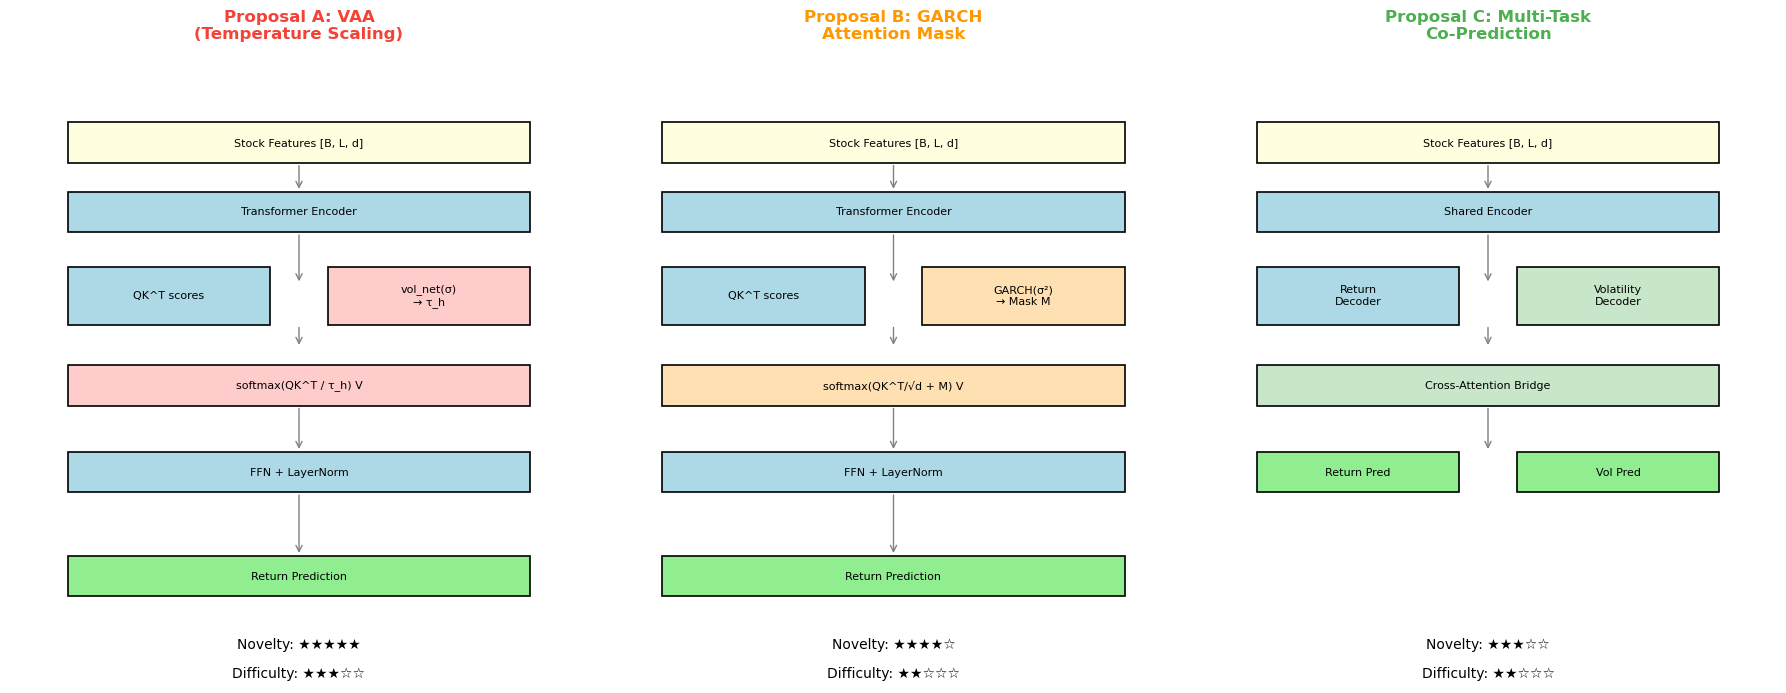

In [16]:
# Side-by-side comparison visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

proposals = [
    {
        'name': 'Proposal A: VAA\n(Temperature Scaling)',
        'color': C_RED,
        'boxes': [
            (1, 9, 8, 0.7, 'Stock Features [B, L, d]', 'lightyellow'),
            (1, 7.8, 8, 0.7, 'Transformer Encoder', 'lightblue'),
            (1, 6.2, 3.5, 1.0, 'QK^T scores', 'lightblue'),
            (5.5, 6.2, 3.5, 1.0, 'vol_net(σ)\n→ τ_h', '#ffcccc'),
            (1, 4.8, 8, 0.7, 'softmax(QK^T / τ_h) V', '#ffcccc'),
            (1, 3.3, 8, 0.7, 'FFN + LayerNorm', 'lightblue'),
            (1, 1.5, 8, 0.7, 'Return Prediction', 'lightgreen'),
        ],
        'innovation': 'Temperature\nmodulation',
        'novelty': '★★★★★',
        'difficulty': '★★★☆☆',
    },
    {
        'name': 'Proposal B: GARCH\nAttention Mask',
        'color': C_ORANGE,
        'boxes': [
            (1, 9, 8, 0.7, 'Stock Features [B, L, d]', 'lightyellow'),
            (1, 7.8, 8, 0.7, 'Transformer Encoder', 'lightblue'),
            (1, 6.2, 3.5, 1.0, 'QK^T scores', 'lightblue'),
            (5.5, 6.2, 3.5, 1.0, 'GARCH(σ²)\n→ Mask M', '#ffe0b2'),
            (1, 4.8, 8, 0.7, 'softmax(QK^T/√d + M) V', '#ffe0b2'),
            (1, 3.3, 8, 0.7, 'FFN + LayerNorm', 'lightblue'),
            (1, 1.5, 8, 0.7, 'Return Prediction', 'lightgreen'),
        ],
        'innovation': 'Adaptive\nmasking',
        'novelty': '★★★★☆',
        'difficulty': '★★☆☆☆',
    },
    {
        'name': 'Proposal C: Multi-Task\nCo-Prediction',
        'color': C_GREEN,
        'boxes': [
            (1, 9, 8, 0.7, 'Stock Features [B, L, d]', 'lightyellow'),
            (1, 7.8, 8, 0.7, 'Shared Encoder', 'lightblue'),
            (1, 6.2, 3.5, 1.0, 'Return\nDecoder', 'lightblue'),
            (5.5, 6.2, 3.5, 1.0, 'Volatility\nDecoder', '#c8e6c9'),
            (1, 4.8, 8, 0.7, 'Cross-Attention Bridge', '#c8e6c9'),
            (1, 3.3, 3.5, 0.7, 'Return Pred', 'lightgreen'),
            (5.5, 3.3, 3.5, 0.7, 'Vol Pred', 'lightgreen'),
        ],
        'innovation': 'Cross-task\nattention',
        'novelty': '★★★☆☆',
        'difficulty': '★★☆☆☆',
    },
]

for ax, prop in zip(axes, proposals):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 11)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(prop['name'], fontweight='bold', fontsize=12, color=prop['color'])
    
    for x, y, w, h, text, color in prop['boxes']:
        ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color, 
                     edgecolor='black', linewidth=1.2, zorder=2))
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=8, zorder=3)
    
    # Arrows between sequential boxes
    y_positions = sorted(set(b[1] for b in prop['boxes']), reverse=True)
    for i in range(len(y_positions) - 1):
        y_from = y_positions[i]
        y_to = y_positions[i+1]
        h_from = [b[3] for b in prop['boxes'] if b[1] == y_from][0]
        ax.annotate('', xy=(5, y_to + h_from), xytext=(5, y_from),
                   arrowprops=dict(arrowstyle='->', color='gray', lw=1))
    
    # Ratings
    ax.text(5, 0.6, f'Novelty: {prop["novelty"]}', ha='center', fontsize=10)
    ax.text(5, 0.1, f'Difficulty: {prop["difficulty"]}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

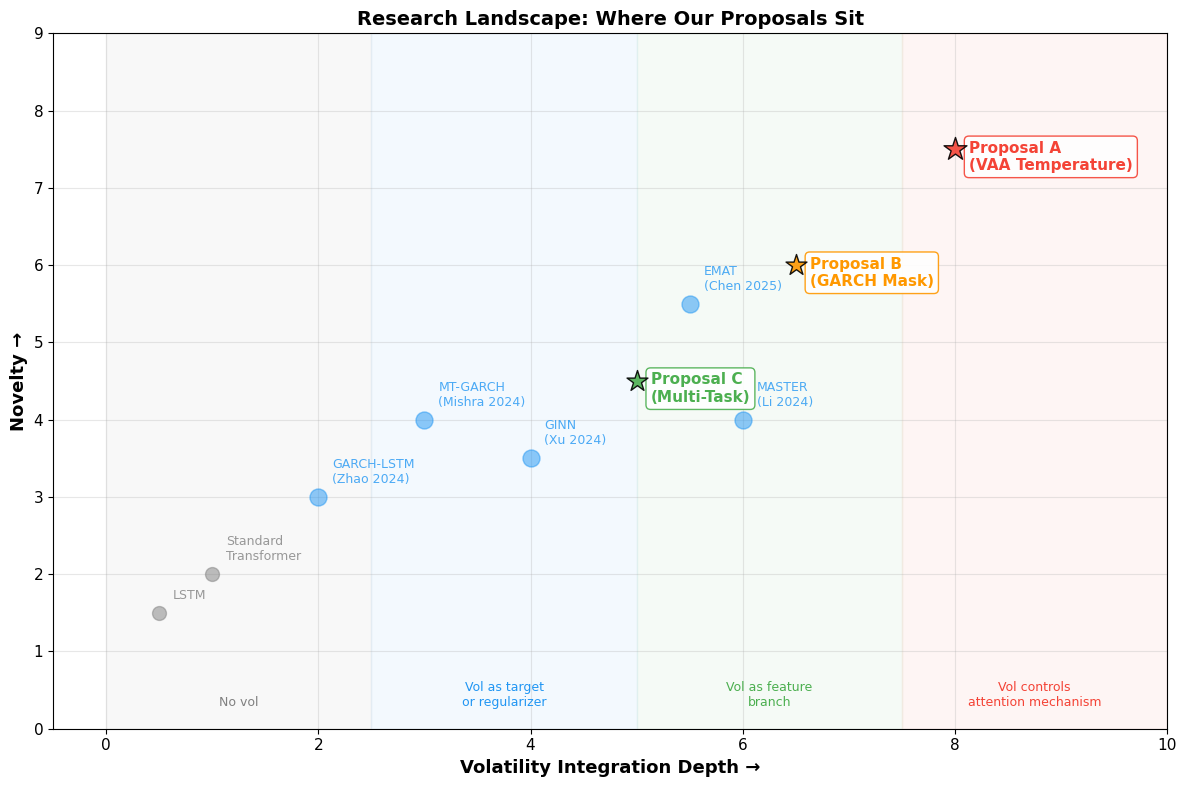


CONCLUSION

Proposal A (VAA) occupies a unique position in the landscape:
  - Deepest integration of volatility (controls the mechanism itself)
  - Highest novelty (no prior work uses vol for attention temperature)
  - Minimal extra parameters (~200 params added to a ~500K model)
  - Clear financial interpretation (testable hypothesis)

The key differentiator from EMAT (closest competitor):
  EMAT: volatility is an ADDITIVE gating branch (one of 3 enhancements)
  VAA:  volatility is a MULTIPLICATIVE temperature control on softmax
       + per-head + multi-scale = richer, more interpretable mechanism


In [17]:
# Final summary: positioning map

fig, ax = plt.subplots(figsize=(12, 8))

# Existing work
existing = [
    ('GARCH-LSTM\n(Zhao 2024)', 2, 3, C_BLUE, 150),
    ('MT-GARCH\n(Mishra 2024)', 3, 4, C_BLUE, 150),
    ('GINN\n(Xu 2024)', 4, 3.5, C_BLUE, 150),
    ('EMAT\n(Chen 2025)', 5.5, 5.5, C_BLUE, 150),
    ('MASTER\n(Li 2024)', 6, 4, C_BLUE, 150),
    ('Standard\nTransformer', 1, 2, 'gray', 100),
    ('LSTM', 0.5, 1.5, 'gray', 100),
]

# Our proposals
ours = [
    ('Proposal A\n(VAA Temperature)', 8, 7.5, C_RED, 300),
    ('Proposal B\n(GARCH Mask)', 6.5, 6, C_ORANGE, 250),
    ('Proposal C\n(Multi-Task)', 5, 4.5, C_GREEN, 250),
]

for name, x, y, color, size in existing:
    ax.scatter(x, y, s=size, c=color, alpha=0.5, zorder=3)
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(10, 10),
               fontsize=9, color=color, alpha=0.8)

for name, x, y, color, size in ours:
    ax.scatter(x, y, s=size, c=color, alpha=0.9, zorder=4, marker='*', edgecolors='black')
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(10, -15),
               fontsize=11, fontweight='bold', color=color,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.9))

ax.set_xlabel('Volatility Integration Depth →', fontsize=13, fontweight='bold')
ax.set_ylabel('Novelty →', fontsize=13, fontweight='bold')
ax.set_title('Research Landscape: Where Our Proposals Sit', fontweight='bold', fontsize=14)
ax.set_xlim(-0.5, 10)
ax.set_ylim(0, 9)

# Dimension labels
ax.axvspan(0, 2.5, alpha=0.05, color='gray')
ax.axvspan(2.5, 5, alpha=0.05, color=C_BLUE)
ax.axvspan(5, 7.5, alpha=0.05, color=C_GREEN)
ax.axvspan(7.5, 10, alpha=0.05, color=C_RED)

ax.text(1.25, 0.3, 'No vol', ha='center', fontsize=9, color='gray')
ax.text(3.75, 0.3, 'Vol as target\nor regularizer', ha='center', fontsize=9, color=C_BLUE)
ax.text(6.25, 0.3, 'Vol as feature\nbranch', ha='center', fontsize=9, color=C_GREEN)
ax.text(8.75, 0.3, 'Vol controls\nattention mechanism', ha='center', fontsize=9, color=C_RED)

plt.tight_layout()
plt.show()

print('\n' + '='*65)
print('CONCLUSION')
print('='*65)
print()
print('Proposal A (VAA) occupies a unique position in the landscape:')
print('  - Deepest integration of volatility (controls the mechanism itself)')
print('  - Highest novelty (no prior work uses vol for attention temperature)')
print('  - Minimal extra parameters (~200 params added to a ~500K model)')
print('  - Clear financial interpretation (testable hypothesis)')
print()
print('The key differentiator from EMAT (closest competitor):')
print('  EMAT: volatility is an ADDITIVE gating branch (one of 3 enhancements)')
print('  VAA:  volatility is a MULTIPLICATIVE temperature control on softmax')
print('       + per-head + multi-scale = richer, more interpretable mechanism')

---

## Quick Reference Card

### Standard Attention
```
Attention = softmax(QK^T / √d_k) V          ← fixed temperature
```

### VAA Attention (our contribution)
```
s_h = 0.5 + 1.5 * sigmoid(MLP([σ_5, σ_10, σ_20, σ_60]))   ← per-head scale
τ_h = √d_k × s_h                                            ← variable temperature
Attention = softmax(QK^T / τ_h) V                            ← volatility-aware!
```

### How it differs from existing work
| Paper | Where vol enters | Mechanism | Target |
|-------|:---:|:---:|:---:|
| GARCH-LSTM | Architecture (output gate) | Gate replacement | σ² |
| GINN | Loss function | MSE regularizer | σ² |
| EMAT | Feature branch (additive gate) | Parallel attention branch | Price |
| **VAA (ours)** | **Attention temperature** | **Softmax divisor, per-head** | **Return** |

### Key design hypothesis (to validate experimentally)
- High volatility → higher temperature → flatter attention → diversified focus
- Low volatility → lower temperature → sharper attention → concentrated focus